<a href="https://colab.research.google.com/github/husnakamilaa/stunting_lens/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PREPARE DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df1 = pd.read_csv('/content/drive/MyDrive/SEM5/02. BIGDATA/PROJECT AKHIR/DATASET/csv/percobaan1_TA_csv.csv')
df1.head()

,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,tahun,jmlBayiGiziKurang,...,desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,terdapat_Pembentukan_RDS/TPPS,"terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",aktivitas_rutin_Penyelenggaraan_posyandu_,Aktivitas_rutin_Penyelenggaraan_kelas_Bina_Keluarga_Balita_,Aktivitas_rutin_Penyelenggaraan_PAUD,Terdapat_Pengembangan_Program_Ketahanan_Pangan,Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun
0,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012001,KEUDE BAKONGAN,2023,0.0,...,Ya,Ya,0.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
1,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012002,UJONG MANGKI,2023,0.0,...,Ya,Ya,8000000.0,Tidak Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
2,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012003,UJONG PADANG,2023,9.0,...,Ya,Ya,0.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
3,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012004,GAMPONG DRIEN,2023,0.0,...,Ya,Ya,0.0,Tidak Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
4,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012015,DARUL IKHSAN,2023,4.0,...,Ya,Ya,19800000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75265 entries, 0 to 75264
Data columns (total 33 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   KODE_PROV                                                                                                             75265 non-null  int64  
 1   NAMA_PROVINSI                                                                                                         75265 non-null  object 
 2   KODE_KAB                                                                                                              75265 non-null  int64  
 3   NAMA_KABUPATEN                                                                                                        75265 non-null  object 
 4   KODE

In [ ]:
num_unique_provinces_by_code = df1['KODE_PROV'].nunique()
print(f"Number of unique provinces (based on KODE_PROV): {num_unique_provinces_by_code}")

Number of unique provinces (based on KODE_PROV): 36


In [ ]:
provinces_with_nan_stunting = df1[df1['jmlBayiStunting'].isna()]['NAMA_PROVINSI'].unique()
num_provinces = len(provinces_with_nan_stunting)

print(f"Unique provinces with NaN values in 'jmlBayiStunting': {provinces_with_nan_stunting}")
print(f"Number of unique provinces with NaN values in 'jmlBayiStunting': {num_provinces}")

Unique provinces with NaN values in 'jmlBayiStunting': ['PAPUA BARAT' 'PAPUA SELATAN' 'PAPUA TENGAH' 'PAPUA PEGUNUNGAN']
Number of unique provinces with NaN values in 'jmlBayiStunting': 4


NameError: name 'df_aceh' is not defined

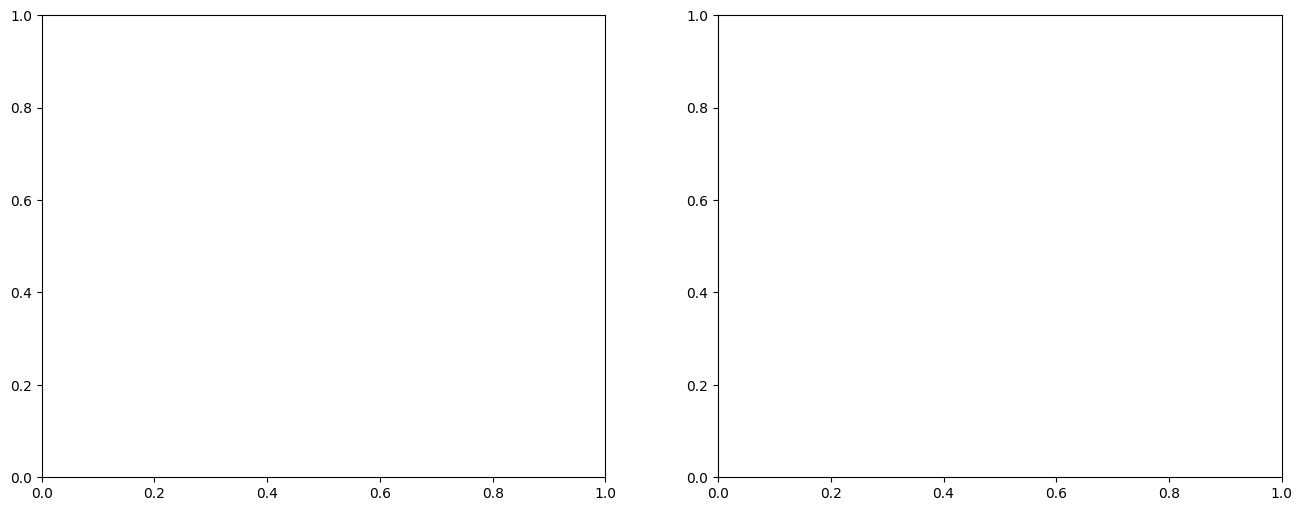

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(y=df_aceh['jmlBayiStunting'].dropna(), ax=axes[0])
axes[0].set_title('Boxplot of jmlBayiStunting in ACEH Province')
axes[0].set_ylabel('Jumlah Bayi Stunting')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Violin Plot
sns.violinplot(y=df_aceh['jmlBayiStunting'].dropna(), ax=axes[1])
axes[1].set_title('Violin Plot of jmlBayiStunting in ACEH Province')
axes[1].set_ylabel('Jumlah Bayi Stunting')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df1[(df1['jmlBayiStunting'] > 100.0) & (df1['NAMA_PROVINSI'] == 'ACEH')]

,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,tahun,jmlBayiGiziKurang,...,desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,terdapat_Pembentukan_RDS/TPPS,"terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",aktivitas_rutin_Penyelenggaraan_posyandu_,Aktivitas_rutin_Penyelenggaraan_kelas_Bina_Keluarga_Balita_,Aktivitas_rutin_Penyelenggaraan_PAUD,Terdapat_Pengembangan_Program_Ketahanan_Pangan,Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun
2073,11,ACEH,1106,ACEH BESAR,110609,MESJID RAYA,1106092012,NEUHEUN,2023,24.0,...,Ya,Tidak,0.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
3945,11,ACEH,1108,ACEH UTARA,110825,GEUREDONG PASE,1108252011,SUKA DAMAI,2023,0.0,...,Ya,Ya,40000000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
4148,11,ACEH,1110,ACEH SINGKIL,111006,GUNUNG MERIAH,1110062006,TANAH BARA,2023,17.0,...,Ya,Ya,20000000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
5862,11,ACEH,1117,BENER MERIAH,111706,WIH PESAM,1117062004,PANTE RAYA,2023,169.0,...,Ya,Ya,55800000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
6416,11,ACEH,1174,KOTA LANGSA,117405,LANGSA BARO,1174052011,LENGKONG,2023,207.0,...,Ya,Ya,0.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada


In [ ]:
df_aceh = df1[df1['NAMA_PROVINSI'] == 'ACEH']
min_stunting_aceh = df_aceh['jmlBayiStunting'].min()
max_stunting_aceh = df_aceh['jmlBayiStunting'].max()

print(f"Minimum 'jmlBayiStunting' in ACEH: {min_stunting_aceh}")
print(f"Maximum 'jmlBayiStunting' in ACEH: {max_stunting_aceh}")

Minimum 'jmlBayiStunting' in ACEH: 0.0
Maximum 'jmlBayiStunting' in ACEH: 207.0


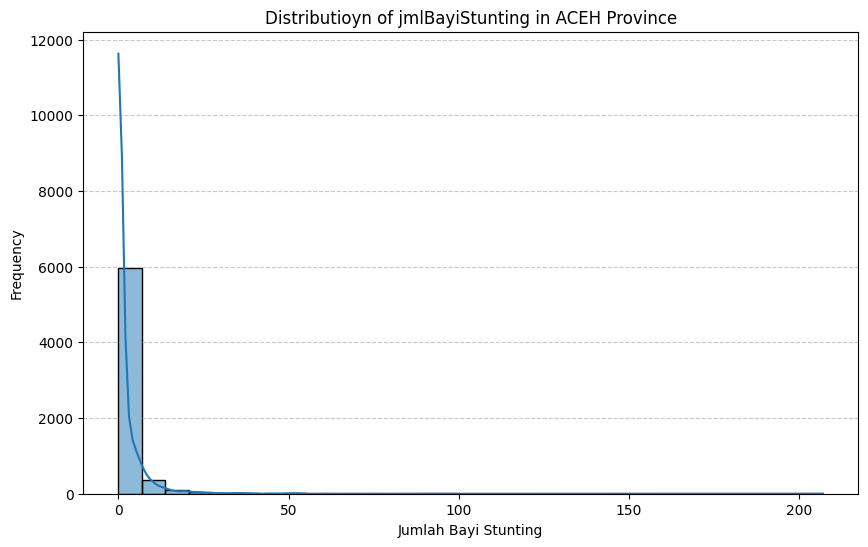

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_aceh['jmlBayiStunting'].dropna(), bins=30, kde=True)
plt.title('Distributioyn of jmlBayiStunting in ACEH Province')
plt.xlabel('Jumlah Bayi Stunting')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

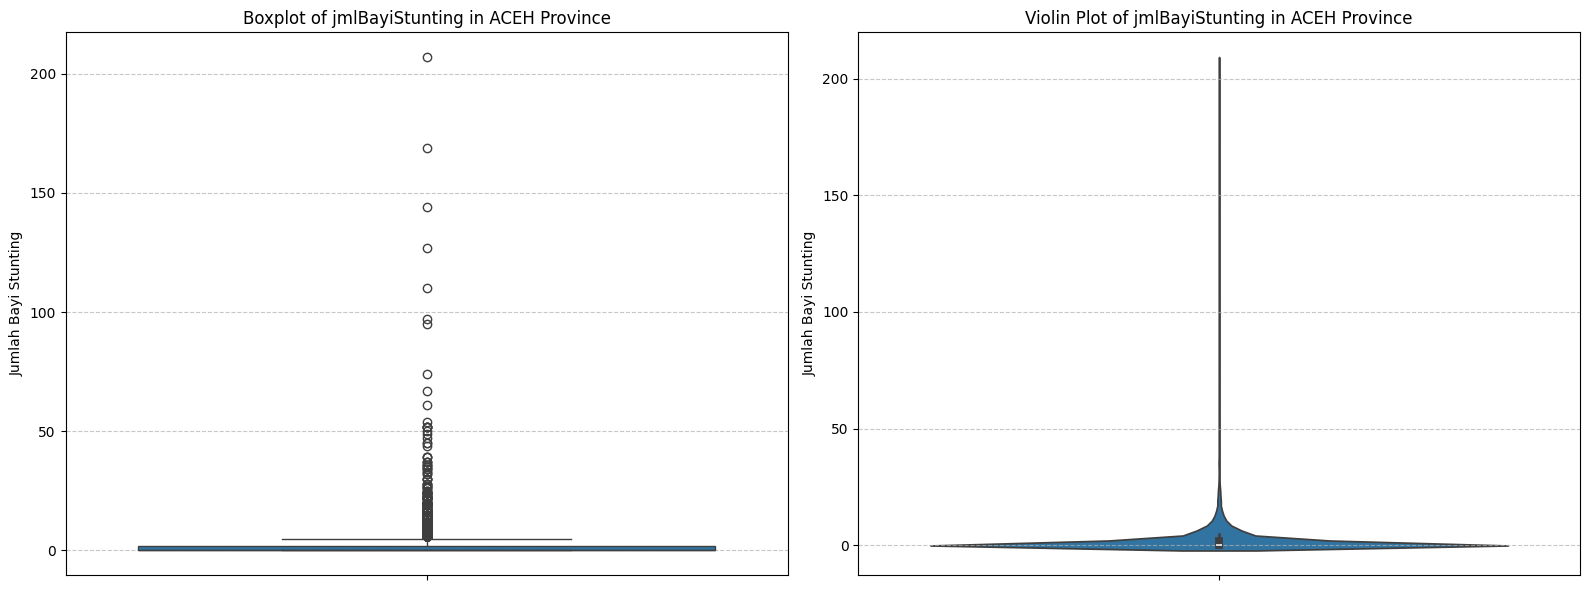

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(y=df_aceh['jmlBayiStunting'].dropna(), ax=axes[0])
axes[0].set_title('Boxplot of jmlBayiStunting in ACEH Province')
axes[0].set_ylabel('Jumlah Bayi Stunting')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Violin Plot
sns.violinplot(y=df_aceh['jmlBayiStunting'].dropna(), ax=axes[1])
axes[1].set_title('Violin Plot of jmlBayiStunting in ACEH Province')
axes[1].set_ylabel('Jumlah Bayi Stunting')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
print(f"IQR (Interquartile Range) for 'jmlBayiStunting' in ACEH: {iqr_stunting_aceh}")
print(f"Mean of 'jmlBayiStunting' in ACEH: {mean_stunting_aceh}")

NameError: name 'iqr_stunting_aceh' is not defined

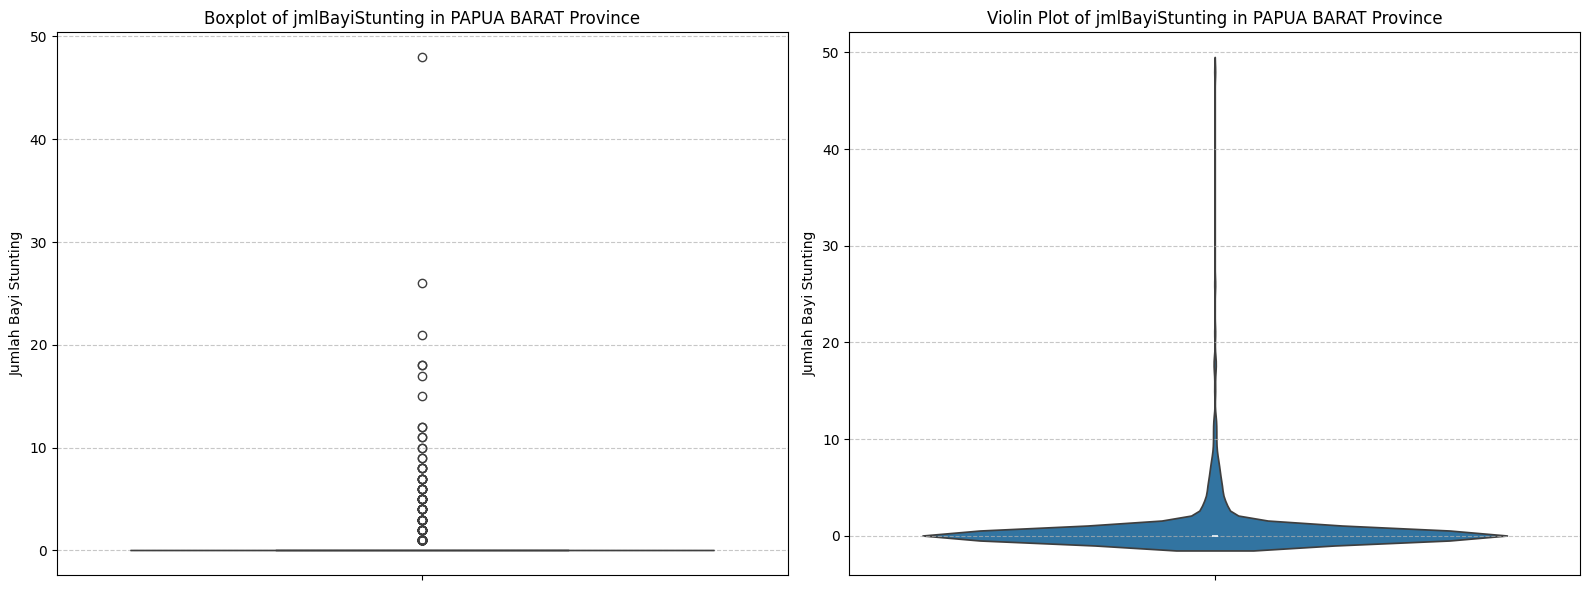

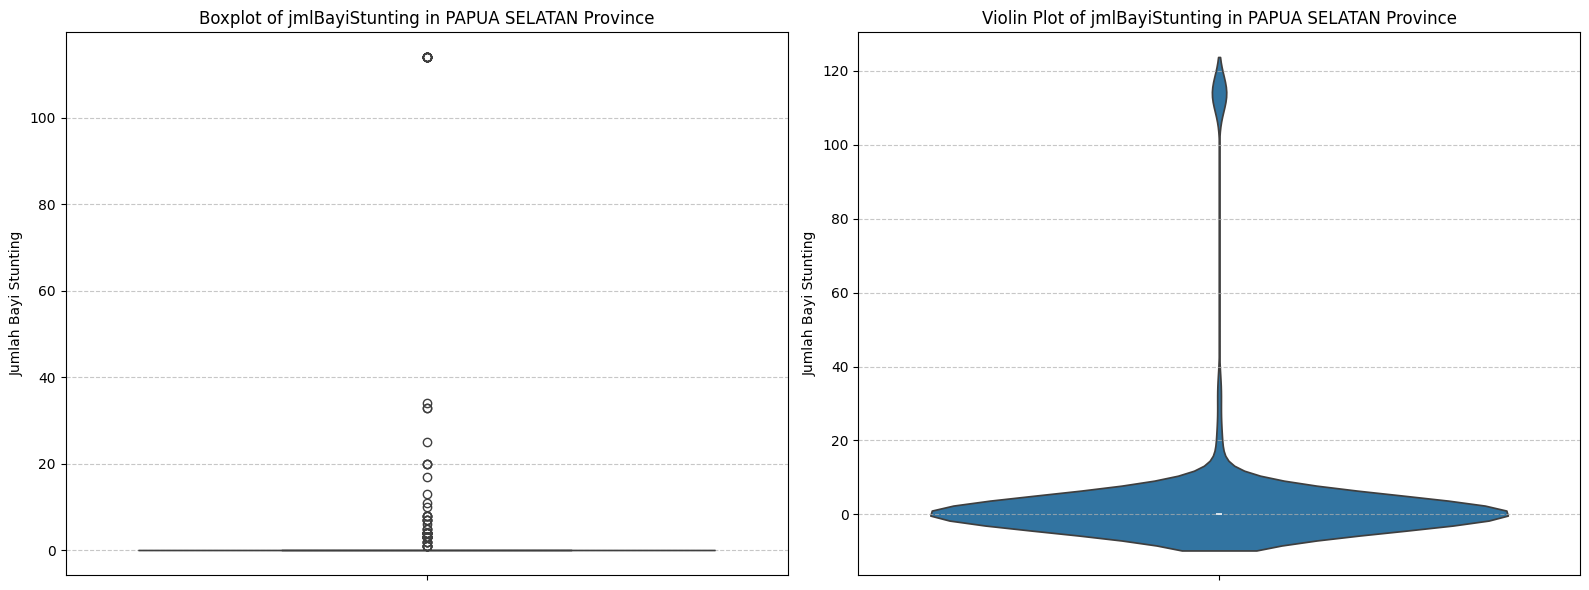

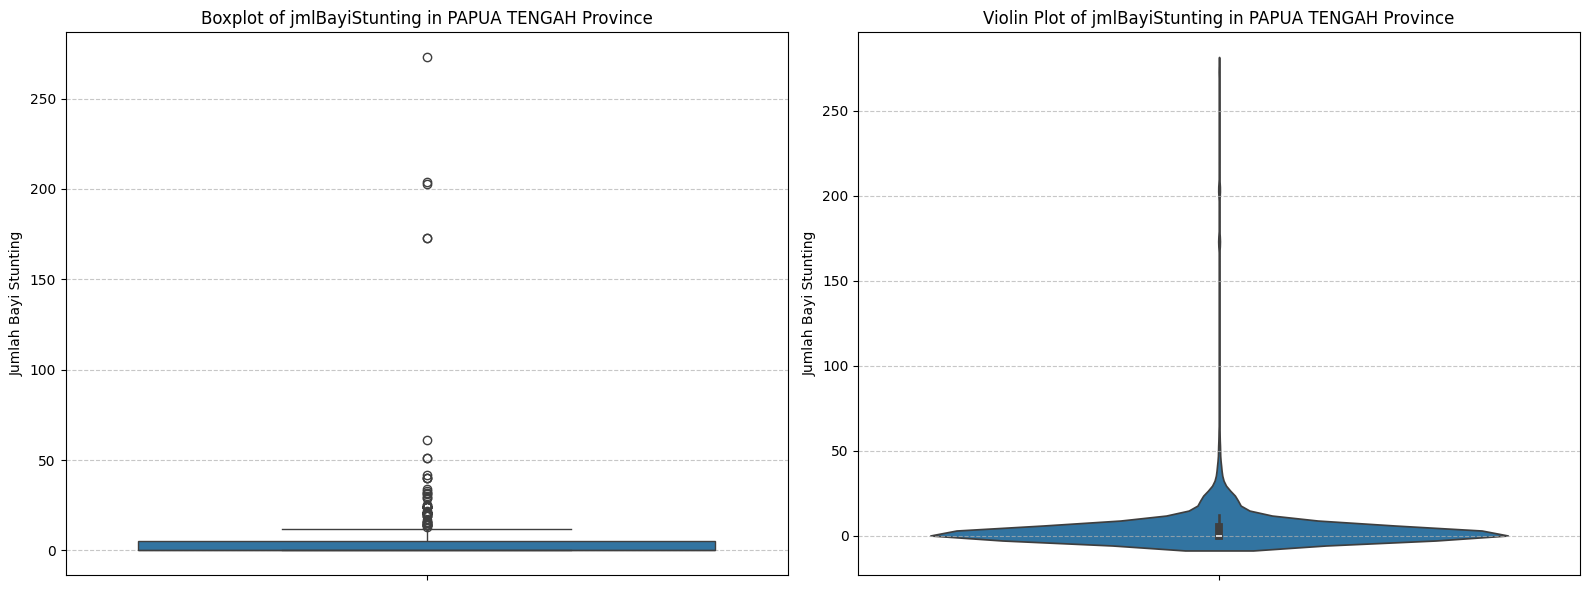

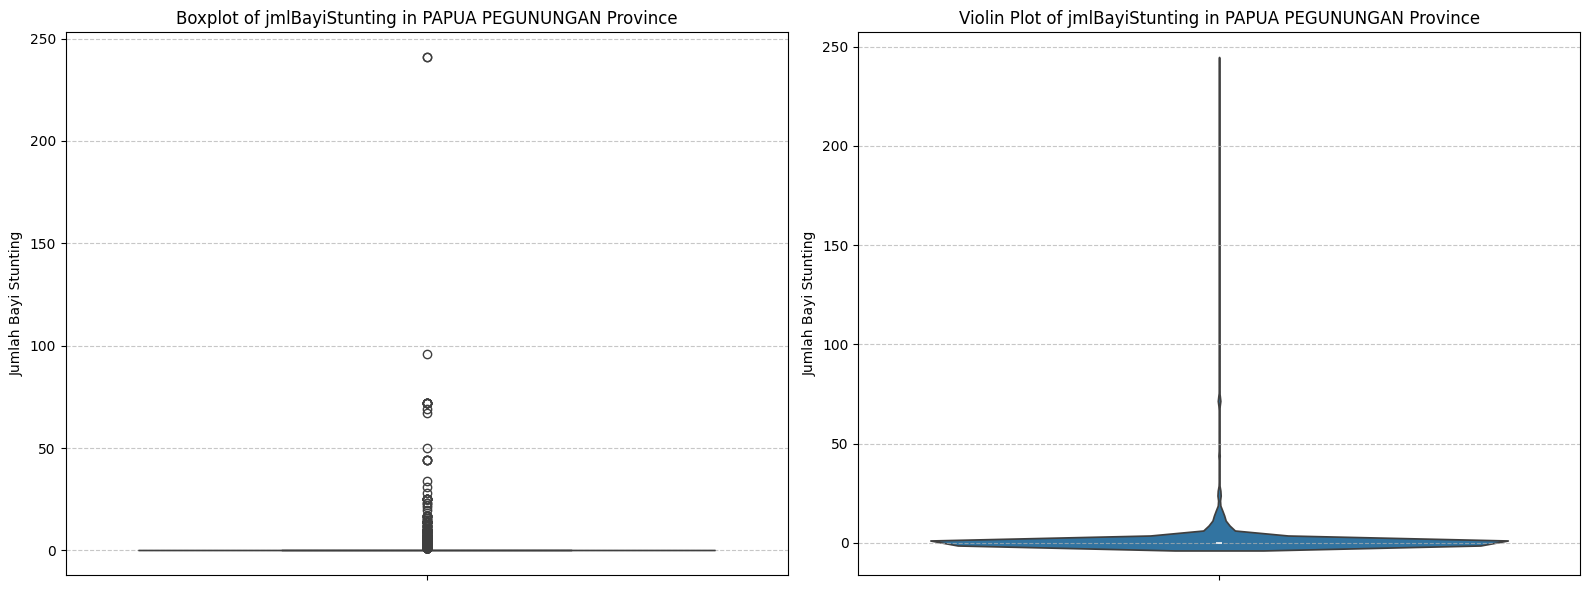

Generated boxplot and violin plots for 'jmlBayiStunting' for all specified provinces.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for province_name in provinces_with_nan_stunting:
    # Filter data for the current province
    df_province = df1[df1['NAMA_PROVINSI'] == province_name]

    # Create a figure with two subplots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot
    sns.boxplot(y=df_province['jmlBayiStunting'].dropna(), ax=axes[0])
    axes[0].set_title(f'Boxplot of jmlBayiStunting in {province_name} Province')
    axes[0].set_ylabel('Jumlah Bayi Stunting')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Violin Plot
    sns.violinplot(y=df_province['jmlBayiStunting'].dropna(), ax=axes[1])
    axes[1].set_title(f'Violin Plot of jmlBayiStunting in {province_name} Province')
    axes[1].set_ylabel('Jumlah Bayi Stunting')
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

print("Generated boxplot and violin plots for 'jmlBayiStunting' for all specified provinces.")

In [ ]:
for province_name in provinces_with_nan_stunting:
    df_province = df1[df1['NAMA_PROVINSI'] == province_name]

    q1_stunting_province = df_province['jmlBayiStunting'].quantile(0.25)
    q3_stunting_province = df_province['jmlBayiStunting'].quantile(0.75)
    iqr_stunting_province = q3_stunting_province - q1_stunting_province
    mean_stunting_province = df_province['jmlBayiStunting'].mean()

    print(f"\n--- {province_name} Province ---")
    print(f"IQR (Interquartile Range) for 'jmlBayiStunting': {iqr_stunting_province}")
    print(f"Mean of 'jmlBayiStunting': {mean_stunting_province}")


--- PAPUA BARAT Province ---
IQR (Interquartile Range) for 'jmlBayiStunting': 0.0
Mean of 'jmlBayiStunting': 0.7316455696202532

--- PAPUA SELATAN Province ---
IQR (Interquartile Range) for 'jmlBayiStunting': 0.0
Mean of 'jmlBayiStunting': 3.404255319148936

--- PAPUA TENGAH Province ---
IQR (Interquartile Range) for 'jmlBayiStunting': 5.0
Mean of 'jmlBayiStunting': 4.526966292134832

--- PAPUA PEGUNUNGAN Province ---
IQR (Interquartile Range) for 'jmlBayiStunting': 0.0
Mean of 'jmlBayiStunting': 1.4459349593495936


In [ ]:
for province_name in provinces_with_nan_stunting:
    df_province = df1[df1['NAMA_PROVINSI'] == province_name]
    data = df_province['jmlBayiStunting']

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    mean = data.mean()

    if iqr == 0:
        lower = data.quantile(0.05)
        upper = data.quantile(0.95)
        method = "Percentile 5%–95%"
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        method = "IQR-based (1.5×IQR)"

    lower = max(lower, 0)

    print(f"\n--- {province_name} Province ---")
    print(f"IQR  : {iqr}")
    print(f"Mean : {mean}")
    print(f"Lower bound : {lower}")
    print(f"Upper bound : {upper}")
    print(f"Method used: {method}")



--- PAPUA BARAT Province ---
IQR  : 0.0
Mean : 0.7316455696202532
Lower bound : 0.0
Upper bound : 5.0
Method used: Percentile 5%–95%

--- PAPUA SELATAN Province ---
IQR  : 0.0
Mean : 3.404255319148936
Lower bound : 0.0
Upper bound : 7.0
Method used: Percentile 5%–95%

--- PAPUA TENGAH Province ---
IQR  : 5.0
Mean : 4.526966292134832
Lower bound : 0
Upper bound : 12.5
Method used: IQR-based (1.5×IQR)

--- PAPUA PEGUNUNGAN Province ---
IQR  : 0.0
Mean : 1.4459349593495936
Lower bound : 0.0
Upper bound : 7.0
Method used: Percentile 5%–95%


In [ ]:
for province_name in sorted(df1['NAMA_PROVINSI'].unique()):
    df_province = df1[df1['NAMA_PROVINSI'] == province_name]
    data = df_province['jmlBayiStunting']

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    mean = data.mean()

    if iqr == 0:
        lower = data.quantile(0.05)
        upper = data.quantile(0.95)
        method = "Percentile 5%–95%"
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        method = "IQR-based (1.5×IQR)"

    lower = max(lower, 0)

    print(f"\n--- {province_name} ---")
    print(f"Jumlah data : {len(data)}")
    print(f"IQR         : {iqr}")
    print(f"Mean        : {mean}")
    print(f"Lower bound : {lower}")
    print(f"Upper bound : {upper}")
    print(f"Method      : {method}")



--- ACEH ---
Jumlah data : 6500
IQR         : 2.0
Mean        : 1.9406153846153846
Lower bound : 0
Upper bound : 5.0
Method      : IQR-based (1.5×IQR)

--- BALI ---
Jumlah data : 636
IQR         : 1.0
Mean        : 2.5235849056603774
Lower bound : 0
Upper bound : 2.5
Method      : IQR-based (1.5×IQR)

--- BANTEN ---
Jumlah data : 1238
IQR         : 0.0
Mean        : 2.7261712439418417
Lower bound : 0.0
Upper bound : 14.149999999999864
Method      : Percentile 5%–95%

--- BENGKULU ---
Jumlah data : 1341
IQR         : 0.0
Mean        : 1.0902311707680836
Lower bound : 0.0
Upper bound : 6.0
Method      : Percentile 5%–95%

--- DAERAH ISTIMEWA YOGYAKARTA ---
Jumlah data : 392
IQR         : 19.25
Mean        : 13.665816326530612
Lower bound : 0
Upper bound : 48.125
Method      : IQR-based (1.5×IQR)

--- GORONTALO ---
Jumlah data : 657
IQR         : 3.0
Mean        : 2.980213089802131
Lower bound : 0
Upper bound : 7.5
Method      : IQR-based (1.5×IQR)

--- JAMBI ---
Jumlah data : 1414
IQR  

In [ ]:
for province_name in sorted(df1['NAMA_PROVINSI'].unique()):
    df_province = df1[df1['NAMA_PROVINSI'] == province_name]
    data = df_province['jmlBayiStunting']

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    mean = data.mean()

    if iqr == 0:
        lower = data.quantile(0.05)
        upper = data.quantile(0.95)
        method = "Percentile 5%–95%"
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        method = "IQR-based (1.5×IQR)"

    lower = max(lower, 0)

    print(f"\n--- {province_name} ---")
    print(f"Jumlah data : {len(data)}")
    print(f"IQR         : {iqr}")
    print(f"Mean        : {mean}")
    print(f"Lower bound : {lower}")
    print(f"Upper bound : {upper}")
    print(f"Method      : {method}")



--- ACEH ---
Jumlah data : 6500
IQR         : 2.0
Mean        : 1.9406153846153846
Lower bound : 0
Upper bound : 5.0
Method      : IQR-based (1.5×IQR)

--- BALI ---
Jumlah data : 636
IQR         : 1.0
Mean        : 2.5235849056603774
Lower bound : 0
Upper bound : 2.5
Method      : IQR-based (1.5×IQR)

--- BANTEN ---
Jumlah data : 1238
IQR         : 0.0
Mean        : 2.7261712439418417
Lower bound : 0.0
Upper bound : 14.149999999999864
Method      : Percentile 5%–95%

--- BENGKULU ---
Jumlah data : 1341
IQR         : 0.0
Mean        : 1.0902311707680836
Lower bound : 0.0
Upper bound : 6.0
Method      : Percentile 5%–95%

--- DAERAH ISTIMEWA YOGYAKARTA ---
Jumlah data : 392
IQR         : 19.25
Mean        : 13.665816326530612
Lower bound : 0
Upper bound : 48.125
Method      : IQR-based (1.5×IQR)

--- GORONTALO ---
Jumlah data : 657
IQR         : 3.0
Mean        : 2.980213089802131
Lower bound : 0
Upper bound : 7.5
Method      : IQR-based (1.5×IQR)

--- JAMBI ---
Jumlah data : 1414
IQR  

In [ ]:
for province_name in sorted(df1_clean['NAMA_PROVINSI'].unique()):
    df_province = df1_clean[df1_clean['NAMA_PROVINSI'] == province_name]
    data = df_province['jmlBayiStunting']

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    mean = data.mean()

    if iqr == 0:
        lower = data.quantile(0.05)
        upper = data.quantile(0.95)
        method = "Percentile 5%–95%"
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        method = "IQR-based (1.5×IQR)"

    lower = max(lower, 0)

    print(f"\n--- {province_name} ---")
    print(f"Jumlah data : {len(data)}")
    print(f"IQR         : {iqr}")
    print(f"Mean        : {mean}")
    print(f"Lower bound : {lower}")
    print(f"Upper bound : {upper}")
    print(f"Method      : {method}")


NameError: name 'df1_clean' is not defined

In [ ]:
for province_name in sorted(df1['NAMA_PROVINSI'].unique()):
    df_province = df1[df1['NAMA_PROVINSI'] == province_name]
    data = df_province['jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb)']

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    mean = data.mean()

    if iqr == 0:
        lower = data.quantile(0.05)
        upper = data.quantile(0.95)
        method = "Percentile 5%–95%"
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        method = "IQR-based (1.5×IQR)"

    lower = max(lower, 0)

    print(f"\n--- {province_name} ---")
    print(f"Jumlah data : {len(data)}")
    print(f"IQR         : {iqr}")
    print(f"Mean        : {mean}")
    print(f"Lower bound : {lower}")
    print(f"Upper bound : {upper}")
    print(f"Method      : {method}")



--- ACEH ---
Jumlah data : 6500
IQR         : 21.0
Mean        : 15.630307692307692
Lower bound : 0
Upper bound : 52.5
Method      : IQR-based (1.5×IQR)

--- BALI ---
Jumlah data : 636
IQR         : 62.0
Mean        : 66.09276729559748
Lower bound : 0
Upper bound : 155.0
Method      : IQR-based (1.5×IQR)

--- BANTEN ---
Jumlah data : 1238
IQR         : 8.75
Mean        : 18.724555735056544
Lower bound : 0
Upper bound : 21.875
Method      : IQR-based (1.5×IQR)

--- BENGKULU ---
Jumlah data : 1341
IQR         : 24.0
Mean        : 20.48993288590604
Lower bound : 0
Upper bound : 60.0
Method      : IQR-based (1.5×IQR)

--- DAERAH ISTIMEWA YOGYAKARTA ---
Jumlah data : 392
IQR         : 114.25
Mean        : 91.19642857142857
Lower bound : 0
Upper bound : 285.625
Method      : IQR-based (1.5×IQR)

--- GORONTALO ---
Jumlah data : 657
IQR         : 37.0
Mean        : 29.40639269406393
Lower bound : 0
Upper bound : 92.5
Method      : IQR-based (1.5×IQR)

--- JAMBI ---
Jumlah data : 1414
IQR     

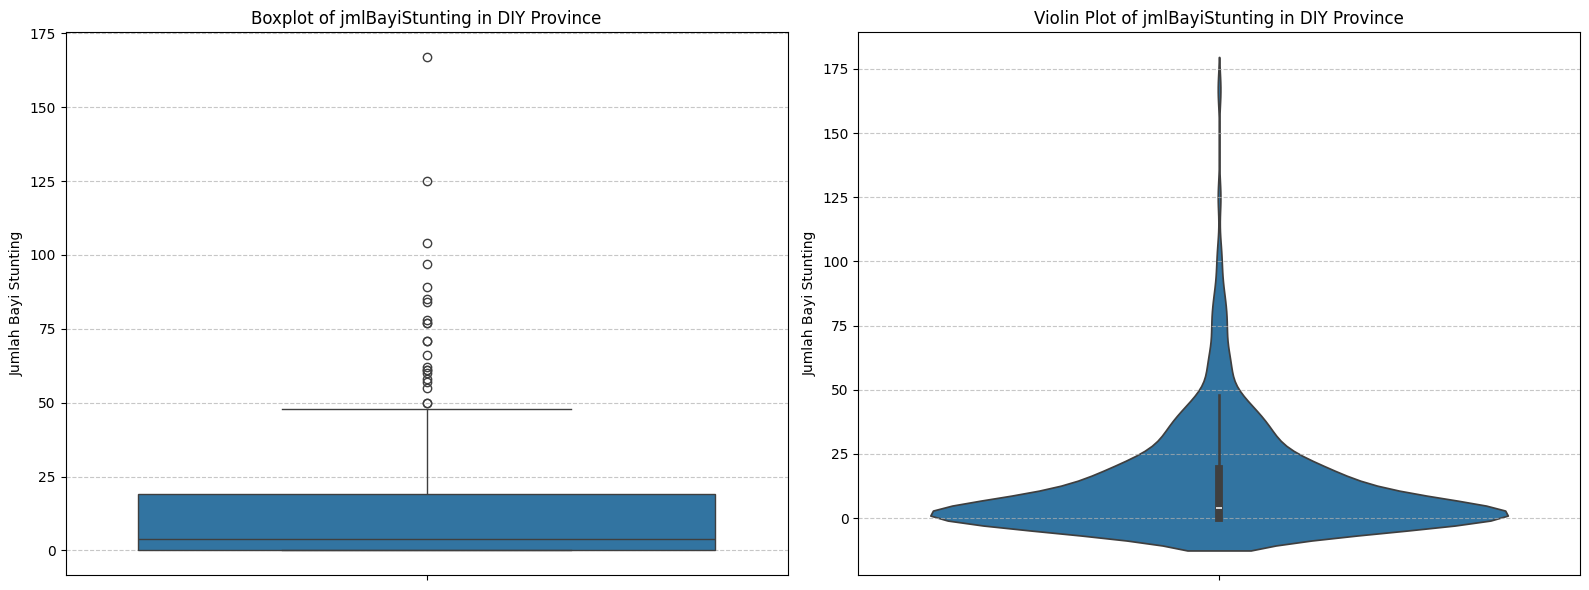

In [ ]:
df_diy = df1[df1['NAMA_PROVINSI'] == 'DAERAH ISTIMEWA YOGYAKARTA']

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    y=df_diy['jmlBayiStunting'].dropna(),
    ax=axes[0]
)
axes[0].set_title('Boxplot of jmlBayiStunting in DIY Province')
axes[0].set_ylabel('Jumlah Bayi Stunting')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Violin Plot
sns.violinplot(
    y=df_diy['jmlBayiStunting'].dropna(),
    ax=axes[1]
)
axes[1].set_title('Violin Plot of jmlBayiStunting in DIY Province')
axes[1].set_ylabel('Jumlah Bayi Stunting')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
df_diy = df1_clean[df1_clean['NAMA_PROVINSI'] == 'DAERAH ISTIMEWA YOGYAKARTA']

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    y=df_diy['jmlBayiStunting'].dropna(),
    ax=axes[0]
)
axes[0].set_title('Boxplot of jmlBayiStunting in DIY Province')
axes[0].set_ylabel('Jumlah Bayi Stunting')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Violin Plot
sns.violinplot(
    y=df_diy['jmlBayiStunting'].dropna(),
    ax=axes[1]
)
axes[1].set_title('Violin Plot of jmlBayiStunting in DIY Province')
axes[1].set_ylabel('Jumlah Bayi Stunting')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


NameError: name 'df1_clean' is not defined

In [ ]:
df_diy = df1[df1['NAMA_PROVINSI'] == 'DAERAH ISTIMEWA YOGYAKARTA']

q1 = df_diy['jmlBayiStunting'].quantile(0.25)
q3 = df_diy['jmlBayiStunting'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
upper_bound


np.float64(48.125)

In [ ]:
outlier_diy = df_diy[df_diy['jmlBayiStunting'] > upper_bound]


In [ ]:
outlier_diy[['NAMA_KABUPATEN', 'jmlBayiStunting']] \
    .sort_values('jmlBayiStunting', ascending=False)


,NAMA_KABUPATEN,jmlBayiStunting
36424,BANTUL,167.0
36534,GUNUNGKIDUL,125.0
36643,SLEMAN,104.0
36426,BANTUL,97.0
36578,GUNUNGKIDUL,89.0
36571,GUNUNGKIDUL,85.0
36641,SLEMAN,84.0
36436,BANTUL,78.0
36589,GUNUNGKIDUL,77.0
36590,GUNUNGKIDUL,77.0


In [ ]:
outlier_diy.sort_values(
    'jmlBayiStunting', ascending=False
)


,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,tahun,jmlBayiGiziKurang,...,desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,terdapat_Pembentukan_RDS/TPPS,"terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",aktivitas_rutin_Penyelenggaraan_posyandu_,Aktivitas_rutin_Penyelenggaraan_kelas_Bina_Keluarga_Balita_,Aktivitas_rutin_Penyelenggaraan_PAUD,Terdapat_Pengembangan_Program_Ketahanan_Pangan,Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun
36424,34,DAERAH ISTIMEWA YOGYAKARTA,3402,BANTUL,340210,IMOGIRI,3402102001,SELOPAMIORO,2023,14.0,...,Ya,Ya,263148000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36534,34,DAERAH ISTIMEWA YOGYAKARTA,3403,GUNUNGKIDUL,340309,KARANGMOJO,3403092001,BEJIHARJO,2023,0.0,...,Ya,Ya,0.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36643,34,DAERAH ISTIMEWA YOGYAKARTA,3404,SLEMAN,340407,DEPOK,3404072003,CONDONGCATUR,2023,86.0,...,Ya,Ya,120000000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Tidak,Ada,Ada
36426,34,DAERAH ISTIMEWA YOGYAKARTA,3402,BANTUL,340210,IMOGIRI,3402102003,WUKIRSARI,2023,7.0,...,Ya,Ya,473768000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36578,34,DAERAH ISTIMEWA YOGYAKARTA,3403,GUNUNGKIDUL,340314,GEDANGSARI,3403142001,HARGOMULYO,2023,5.0,...,Ya,Ya,260225000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36571,34,DAERAH ISTIMEWA YOGYAKARTA,3403,GUNUNGKIDUL,340312,SEMIN,3403122010,SEMIN,2023,20.0,...,Ya,Ya,178110000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36641,34,DAERAH ISTIMEWA YOGYAKARTA,3404,SLEMAN,340407,DEPOK,3404072001,CATURTUNGGAL,2023,110.0,...,Ya,Ya,123000000.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36436,34,DAERAH ISTIMEWA YOGYAKARTA,3402,BANTUL,340211,DLINGO,3402112005,TERONG,2023,5.0,...,Ya,Ya,375863100.0,Ada,Ada,Rutin Tiap Bulan,Rutin Tiap Bulan,Rutin Tiap Bulan,Ada,Ada
36589,34,DAERAH ISTIMEWA YOGYAKARTA,3403,GUNUNGKIDUL,340315,SAPTOSARI,3403152005,KANIGORO,2023,7.0,...,Ya,Ya,112410000.0,Ya,Ya,Ya,Ya,Ya,Tidak,Ya
36590,34,DAERAH ISTIMEWA YOGYAKARTA,3403,GUNUNGKIDUL,340315,SAPTOSARI,3403152006,MONGGOL,2023,7.0,...,Ya,Ya,112410000.0,Ya,Ya,Ya,Ya,Ya,Tidak,Ya


In [ ]:
outlier_diy.groupby('NAMA_KABUPATEN')['jmlBayiStunting'] \
    .agg(['count', 'max', 'mean']) \
    .sort_values('max', ascending=False)


,count,max,mean
NAMA_KABUPATEN,,,
BANTUL,5,167.0,93.000000
GUNUNGKIDUL,9,125.0,75.444444
SLEMAN,6,104.0,71.666667
KULON PROGO,2,71.0,65.500000


## ISI MSSING VALUE W/ IQR/PERCENTIL (5-95%)

In [ ]:
numeric_cols = [
    'jmlBayiStunting',
    'jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb)',
    'jumlah_Remaja_Putri_Mendapat_Tablet_Tambah_Darah_(TTB)',
    'jumlah_Ibu_Hamil_Periksa_Kehamilan/Nifas',
    'jumlah_Ibu_Hamil_mengkonsumsi_tablet_tambah_darah_(TTD)_(minimal_90_tablet_selama_masa_kehamilan)',
    'jumlah_Anak_usia_0-59_Bulan_terpantau_tumbuh_kembang_(datang_ke_posyandu/layanan_kesehatan_lainnya)',
    'jumlah_anak_usia_0-59_bulan_mengikuti_kegiatan_BKB/PAUD',
    'jumlah_Anak_usia_0-59_Bulan_mengalami_gizi_kurang/buruk/stunting_mendapatkan_tambahan_asupan_gizi_dan_konseling_gizi',
    'jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap',
    'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum',
    'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.',
    'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_sanitasi/pembuangan_limbah_layak',
    'jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting'
]

df1_clean = df1.copy()

for col in numeric_cols:
    for province_name in df1_clean['NAMA_PROVINSI'].unique():
        mask = df1_clean['NAMA_PROVINSI'] == province_name
        data = df1_clean.loc[mask, col].dropna()

        if data.empty:
            continue

        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            lower = data.quantile(0.05)
            upper = data.quantile(0.95)
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

        lower = max(lower, 0)

        df1_clean.loc[mask, col] = df1_clean.loc[mask, col].clip(lower, upper)


In [ ]:
df1_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75265 entries, 0 to 75264
Data columns (total 33 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   KODE_PROV                                                                                                             75265 non-null  int64  
 1   NAMA_PROVINSI                                                                                                         75265 non-null  object 
 2   KODE_KAB                                                                                                              75265 non-null  int64  
 3   NAMA_KABUPATEN                                                                                                        75265 non-null  object 
 4   KODE

In [ ]:
df_stunting = df1_clean[df1_clean['jmlBayiStunting'].notna()]

In [ ]:
df_stunting.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73761 entries, 0 to 75264
Data columns (total 33 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   KODE_PROV                                                                                                             73761 non-null  int64  
 1   NAMA_PROVINSI                                                                                                         73761 non-null  object 
 2   KODE_KAB                                                                                                              73761 non-null  int64  
 3   NAMA_KABUPATEN                                                                                                        73761 non-null  object 
 4   KODE_KEC 

In [ ]:
num_unique_provinces_df_stunting = df_stunting['NAMA_PROVINSI'].nunique()
print(f"The df_stunting DataFrame contains data from {num_unique_provinces_df_stunting} unique provinces.")

The df_stunting DataFrame contains data from 36 unique provinces.


In [ ]:
object_cols_fill0 = [
    'desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD',
    'terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa',
    'terdapat_Pembentukan_RDS/TPPS',
    'terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas',
    'aktivitas_rutin_Penyelenggaraan_posyandu_',
    'Aktivitas_rutin_Penyelenggaraan_kelas_Bina_Keluarga_Balita_',
    'Aktivitas_rutin_Penyelenggaraan_PAUD',
    'Terdapat_Pengembangan_Program_Ketahanan_Pangan',
    'Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun'
]


df_stunting[object_cols_fill0] = df_stunting[object_cols_fill0].fillna(0)


/tmp/ipykernel_3202/1172105768.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stunting[object_cols_fill0] = df_stunting[object_cols_fill0].fillna(0)


In [ ]:
cols_drop_gizi = [
    'jmlBayiGiziKurang',
    'jmlBayiGiziBuruk'
]

cols_drop_object = [
    'Aktivitas_rutin_Penyelenggaraan_kelas_Bina_Keluarga_Balita_',
    'Aktivitas_rutin_Penyelenggaraan_PAUD',
    'Terdapat_Pengembangan_Program_Ketahanan_Pangan',
    'Desa_melakukan_monitoring/evaluasi_atas_pelaksanaan_konvergensi_stunting_min._2_kali_dlm_1tahun'
]

cols_to_drop = cols_drop_gizi + cols_drop_object

df_final = df_stunting.drop(columns=cols_to_drop)

df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73761 entries, 0 to 75264
Data columns (total 27 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   KODE_PROV                                                                                                             73761 non-null  int64  
 1   NAMA_PROVINSI                                                                                                         73761 non-null  object 
 2   KODE_KAB                                                                                                              73761 non-null  int64  
 3   NAMA_KABUPATEN                                                                                                        73761 non-null  object 
 4   KODE_KEC 

# BINARY ENCODE

In [ ]:
import pandas as pd

df_final['aktivitas_rutin_Penyelenggaraan_posyandu_'] = (
    df_final['aktivitas_rutin_Penyelenggaraan_posyandu_']
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 'Tidak' if x in ['Tidak', '0', 'Tidak ada'] else 'Iya')
)

In [ ]:
df_final['aktivitas_rutin_Penyelenggaraan_posyandu_'].value_counts()

,count
aktivitas_rutin_Penyelenggaraan_posyandu_,
Iya,73223
Tidak,538


In [ ]:
col = 'terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas'

df_final[col] = (
    df1[col]
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 'Tidak' if x in ['0', 'tidak ada', 'tidak'] else 'Iya')
)

In [ ]:
df_final['terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas'].value_counts()

,count
"terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",
Iya,67050
Tidak,6711


In [ ]:
col = 'terdapat_Pembentukan_RDS/TPPS'

df_final[col] = (
    df_final[col]
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 'Tidak' if x in ['0', 'tidak ada', 'tidak', 'tidak adak', 'tidak adaada'] else 'Iya')
)

In [ ]:
df_final['terdapat_Pembentukan_RDS/TPPS'].value_counts()

,count
terdapat_Pembentukan_RDS/TPPS,
Iya,50534
Tidak,23227


In [ ]:
col = 'terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa'

df_final[col] = (
    df_final[col]
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 'Tidak' if x in ['0', 'tidak ada', 'tidak'] else 'Iya')
)

In [ ]:
df_final['terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa'].value_counts()

,count
terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,
Iya,67750
Tidak,6011


In [ ]:
col = 'desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD'

df_final[col] = (
    df_final[col]
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 'Tidak' if x in ['0', 'tidak ada', 'tidak'] else 'Iya')
)

In [ ]:
df_final['desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD'].value_counts()

,count
desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,
Iya,62430
Tidak,11331


In [ ]:
bool_cols = [
    'desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD',
    'terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa',
    'terdapat_Pembentukan_RDS/TPPS',
    'terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas',
    'aktivitas_rutin_Penyelenggaraan_posyandu_'
]

df_final[bool_cols] = df_final[bool_cols].apply(
    lambda col: col.map({'Iya': 1, 'Tidak': 0})
)


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73761 entries, 0 to 75264
Data columns (total 27 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   KODE_PROV                                                                                                             73761 non-null  int64  
 1   NAMA_PROVINSI                                                                                                         73761 non-null  object 
 2   KODE_KAB                                                                                                              73761 non-null  int64  
 3   NAMA_KABUPATEN                                                                                                        73761 non-null  object 
 4   KODE_KEC 

In [ ]:
csv_path = '/content/drive/MyDrive/SEM5/02. BIGDATA/PROJECT AKHIR/DATASET/csv/bersihWithLabel/datasetRevisi.csv'
df_final.to_csv(csv_path, index=False)

# FEATURE MAP W/ RANDOMFOREST

In [ ]:
import pandas as pd

df2 = pd.read_csv('/content/drive/MyDrive/SEM5/02. BIGDATA/PROJECT AKHIR/DATASET/csv/bersihWithLabel/datasetRevisi.csv')
df2.head()

,KODE_PROV,NAMA_PROVINSI,KODE_KAB,NAMA_KABUPATEN,KODE_KEC,NAMA_KECAMATAN,KODE_DESA,NAMA_DESA,tahun,jmlBayiStunting,...,jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap,jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum,jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.,jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_sanitasi/pembuangan_limbah_layak,desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,terdapat_Pembentukan_RDS/TPPS,"terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",aktivitas_rutin_Penyelenggaraan_posyandu_
0,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012001,KEUDE BAKONGAN,2023,0.0,...,0.0,0.0,0.0,0.0,1,1,0.0,1,1,1
1,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012002,UJONG MANGKI,2023,0.0,...,0.0,5.0,6.0,0.0,1,1,8000000.0,0,1,1
2,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012003,UJONG PADANG,2023,0.0,...,0.0,7.0,6.0,6.0,1,1,0.0,1,1,1
3,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012004,GAMPONG DRIEN,2023,0.0,...,0.0,5.0,5.0,5.0,1,1,0.0,0,1,1
4,11,ACEH,1101,ACEH SELATAN,110101,BAKONGAN,1101012015,DARUL IKHSAN,2023,2.0,...,15.0,5.0,5.0,5.0,1,1,19800000.0,1,1,1


In [ ]:
df2_copy = df2.copy()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# ===============================
# 1. Tentukan kolom yang DIBUANG
# ===============================
cols_drop_id = [
    'KODE_PROV',
    'KODE_KAB',
    'KODE_KEC',
    'KODE_DESA'
]

# ===============================
# 2. Pisahkan X dan y
# ===============================
y = df2_copy['jmlBayiStunting']

X = df2_copy.drop(columns=['jmlBayiStunting'] + cols_drop_id)

# ===============================
# 3. Buang kolom object (nama wilayah)
# ===============================
X = X.select_dtypes(exclude=['object'])

print("Fitur yang dipakai:", X.columns.tolist())

# ===============================
# 4. Train-test split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. Random Forest
# ===============================
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ===============================
# 6. Feature importance
# ===============================
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)


Fitur yang dipakai: ['tahun', 'jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb)', 'jumlah_Remaja_Putri_Mendapat_Tablet_Tambah_Darah_(TTB)', 'jumlah_Ibu_Hamil_Periksa_Kehamilan/Nifas', 'jumlah_Ibu_Hamil_mengkonsumsi_tablet_tambah_darah_(TTD)_(minimal_90_tablet_selama_masa_kehamilan)', 'jumlah_Anak_usia_0-59_Bulan_terpantau_tumbuh_kembang_(datang_ke_posyandu/layanan_kesehatan_lainnya)', 'jumlah_anak_usia_0-59_bulan_mengikuti_kegiatan_BKB/PAUD', 'jumlah_Anak_usia_0-59_Bulan_mengalami_gizi_kurang/buruk/stunting_mendapatkan_tambahan_asupan_gizi_dan_konseling_gizi', 'jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap', 'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum', 'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.', 'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_sanitasi/pembuangan_limbah_layak', 'desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD', 'terdapa

,0
jumlah_Anak_usia_0-59_Bulan_mengalami_gizi_kurang/buruk/stunting_mendapatkan_tambahan_asupan_gizi_dan_konseling_gizi,0.284138
jumlah_Anak_usia_0-59_Bulan_terpantau_tumbuh_kembang_(datang_ke_posyandu/layanan_kesehatan_lainnya),0.146815
jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap,0.068000
jumlah_anak_usia_0-59_bulan_mengikuti_kegiatan_BKB/PAUD,0.063681
jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,0.060560
jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum,0.055706
jumlah_Remaja_Putri_Mendapat_Tablet_Tambah_Darah_(TTB),0.055515
jumlah_Ibu_Hamil_mengkonsumsi_tablet_tambah_darah_(TTD)_(minimal_90_tablet_selama_masa_kehamilan),0.053260
jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.,0.053139
jumlah_Ibu_Hamil_Periksa_Kehamilan/Nifas,0.052891


# SIAP TRAIN

In [ ]:
y = df2['jmlBayiStunting']

In [ ]:
fasilitas_kesehatan = [
    'aktivitas_rutin_Penyelenggaraan_posyandu_',
    'jumlah_Ibu_Hamil_Periksa_Kehamilan/Nifas',
    'jumlah_Anak_usia_0-59_Bulan_terpantau_tumbuh_kembang_(datang_ke_posyandu/layanan_kesehatan_lainnya)',
    'jumlah_anak_usia_0-59_bulan_mengikuti_kegiatan_BKB/PAUD',
    'jumlah_Anak_usia_0-59_bulan_mendapatkan_imunisasi_dasar_lengkap'
]

sanitasi_air = [
    'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_sumber_air_bersih/minum',
    'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_ke_jamban_sehat.',
    'jumlah_Keluarga_beresiko_stunting_dan_keluarga_rentan_memiliki_akses_sanitasi/pembuangan_limbah_layak'
]

layanan_gizi = [
    'jumlah_Remaja_Putri_Ikut_Pemeriksaan_Anemia_(Hb)',
    'jumlah_Remaja_Putri_Mendapat_Tablet_Tambah_Darah_(TTB)',
    'jumlah_Ibu_Hamil_mengkonsumsi_tablet_tambah_darah_(TTD)_(minimal_90_tablet_selama_masa_kehamilan)',
    'jumlah_Anak_usia_0-59_Bulan_mengalami_gizi_kurang/buruk/stunting_mendapatkan_tambahan_asupan_gizi_dan_konseling_gizi'
]

fasilitas_desa = [
    'desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD',
    'terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa',
    'jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting',
    'terdapat_Pembentukan_RDS/TPPS',
    'terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas'
]


In [ ]:
df2[fasilitas_kesehatan].dtypes
df2[sanitasi_air].dtypes
df2[layanan_gizi].dtypes
df2[fasilitas_desa].dtypes

,0
desa_Melaksanakan_rembuk_stunting_desa_dengan_melibatkan_UPTD,int64
terdapat_Penetapan_anggaran__kegiatan_stunting_dalam_APB_Desa,int64
jumlah_alokasi_anggaran_untuk_mendukung_kegiatan_stunting,float64
terdapat_Pembentukan_RDS/TPPS,int64
"terdapat_Pelaku_Desa_(Kader,_KPM,_TPK)_mendapatkan_peningkatan_kapasitas",int64


In [ ]:
df2['Fasilitas_Kesehatan'] = df2[fasilitas_kesehatan].mean(axis=1)
df2['Sanitasi_Air_Bersih'] = df2[sanitasi_air].mean(axis=1)
df2['Layanan_Gizi'] = df2[layanan_gizi].mean(axis=1)
df2['Fasilitas_Desa'] = df2[fasilitas_desa].mean(axis=1)

In [ ]:
print(df2[['Fasilitas_Kesehatan', 'Sanitasi_Air_Bersih', 'Layanan_Gizi', 'Fasilitas_Desa']].mean())

Fasilitas_Kesehatan    3.092736e+01
Sanitasi_Air_Bersih    4.575694e+00
Layanan_Gizi           1.800516e+01
Fasilitas_Desa         4.976422e+06
dtype: float64


In [ ]:
df2[['Fasilitas_Kesehatan',
     'Sanitasi_Air_Bersih',
     'Layanan_Gizi',
     'Fasilitas_Desa']].dtypes


,0
Fasilitas_Kesehatan,float64
Sanitasi_Air_Bersih,float64
Layanan_Gizi,float64
Fasilitas_Desa,float64


In [ ]:
X = df2[
    ['Fasilitas_Kesehatan',
     'Sanitasi_Air_Bersih',
     'Layanan_Gizi',
     'Fasilitas_Desa']
]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svr__C': [1, 10],
    'svr__gamma': ['scale', 0.1],
    'svr__epsilon': [0.1]
}


In [ ]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1 )

print("GridSearch mulai...")
grid.fit(X_train, y_train)
print("GridSearch selesai!")

GridSearch mulai...
GridSearch selesai!


In [ ]:
best_model = grid.best_estimator_
print("Best params:", grid.best_params_)


Best params: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


RMSE: 5.457371177866527
MAE: 2.5341449649228975
R2: 0.11619850132355536


In [ ]:
# SAVE MODEL
import joblib

# Menyimpan best_model hasil training SVR ke file
joblib.dump(best_model, 'model_svr_stunting.joblib')
print("Model berhasil disimpan sebagai 'model_svr_stunting.joblib'!")

Model berhasil disimpan sebagai 'model_svr_stunting.joblib'!
